In [249]:
import pandas as pd
import numpy as np

In [250]:
train_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/Train.csv")
test_df = pd.read_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/Test.csv")

In [251]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity
0,26/09/24,Automotive,BrandA,3,0,17.9,462.30,33.96,359.45,227.0
1,26/09/24,Automotive,BrandA,3,0,66.3,321.28,24.76,49.47,370.0
2,26/09/24,Automotive,BrandA,3,0,14.4,74.85,32.19,245.11,299.0
3,26/09/24,Automotive,BrandA,3,0,34.7,469.12,43.68,144.08,426.0
4,22/09/24,Automotive,BrandA,6,1,93.5,221.76,36.79,478.07,470.0


In [252]:
train_df.shape

(18483, 10)

In [253]:
test_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity
0,15/12/24,Automotive,BrandA,6,1,48.8,150.23,43.58,302.39,NaN
1,15/12/24,Automotive,BrandA,6,1,79.2,344.84,15.17,322.33,NaN
2,07/12/24,Automotive,BrandA,5,0,56.2,459.79,24.89,92.22,NaN
3,07/12/24,Automotive,BrandA,5,0,78.0,117.05,31.89,100.16,NaN
4,03/12/24,Automotive,BrandA,1,0,36.3,408.92,28.48,442.54,NaN


In [254]:
test_df.shape

(1052, 10)

In [255]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18483 entries, 0 to 18482
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  18483 non-null  object 
 1   Category              18483 non-null  object 
 2   Brand                 18483 non-null  object 
 3   Day_of_Week           18483 non-null  int64  
 4   Holiday_Indicator     18483 non-null  int64  
 5   Past_Purchase_Trends  18483 non-null  float64
 6   Price                 18483 non-null  float64
 7   Discount              18483 non-null  float64
 8   Competitor_Price      18483 non-null  float64
 9   Sales_Quantity        18019 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.4+ MB


In [256]:
train_df['price_diff'] = train_df['Price'] - train_df['Competitor_Price']

In [257]:
train_df['is_discounted'] = np.where(train_df['price_diff'] > 0, 1, 0)

In [258]:
train_df['is_discounted'].value_counts(normalize=True) * 100

is_discounted
1    53.146134
0    46.853866
Name: proportion, dtype: float64

In [259]:
test_df['price_diff'] = test_df['Price'] - test_df['Competitor_Price']

In [260]:
test_df['is_discounted'] = np.where(test_df['price_diff'] > 0, 1, 0)

In [261]:
test_df['is_discounted'].value_counts(normalize=True) * 100

is_discounted
1    53.707224
0    46.292776
Name: proportion, dtype: float64

In [262]:
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df['year'] = train_df['Date'].dt.year
train_df['month'] = train_df['Date'].dt.month
train_df['day_of_month'] = train_df['Date'].dt.day

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_51307/3455871574.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_df['Date'] = pd.to_datetime(train_df['Date'])


In [263]:
test_df['Date'] = pd.to_datetime(test_df['Date'])
test_df['year'] = test_df['Date'].dt.year
test_df['month'] = test_df['Date'].dt.month
test_df['day_of_month'] = test_df['Date'].dt.day

/var/folders/pw/wmjkx07d5bj7gwx0bm5zkdjm0000gp/T/ipykernel_51307/322462643.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_df['Date'] = pd.to_datetime(test_df['Date'])


In [264]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity,price_diff,is_discounted,year,month,day_of_month
0,2024-09-26,Automotive,BrandA,3,0,17.9,462.30,33.96,359.45,227.0,102.85,1,2024,9,26
1,2024-09-26,Automotive,BrandA,3,0,66.3,321.28,24.76,49.47,370.0,271.81,1,2024,9,26
2,2024-09-26,Automotive,BrandA,3,0,14.4,74.85,32.19,245.11,299.0,-170.26,0,2024,9,26
3,2024-09-26,Automotive,BrandA,3,0,34.7,469.12,43.68,144.08,426.0,325.04,1,2024,9,26
4,2024-09-22,Automotive,BrandA,6,1,93.5,221.76,36.79,478.07,470.0,-256.31,0,2024,9,22


In [265]:
train_df['is_weekend'] = np.where(train_df['Date'].dt.dayofweek.isin([5, 6]), 1, 0)
test_df['is_weekend'] = np.where(test_df['Date'].dt.dayofweek.isin([5, 6]), 1, 0)

In [266]:
train_df['is_month_start'] = np.where(train_df['Date'].dt.is_month_start, 1, 0)
test_df['is_month_start'] = np.where(test_df['Date'].dt.is_month_start, 1, 0)

In [267]:
train_df['is_month_end'] = np.where(train_df['Date'].dt.is_month_end, 1, 0)
test_df['is_month_end'] = np.where(test_df['Date'].dt.is_month_end, 1, 0)

In [268]:
train_df['is_quarter_start'] = np.where(train_df['Date'].dt.is_quarter_start, 1, 0)
test_df['is_quarter_start'] = np.where(test_df['Date'].dt.is_quarter_start, 1, 0)

In [269]:
train_df['is_quarter_end'] = np.where(train_df['Date'].dt.is_quarter_end, 1, 0)
test_df['is_quarter_end'] = np.where(test_df['Date'].dt.is_quarter_end, 1, 0)

In [270]:
train_df['is_year_start'] = np.where(train_df['Date'].dt.is_year_start, 1, 0)
test_df['is_year_start'] = np.where(test_df['Date'].dt.is_year_start, 1, 0)

In [271]:
train_df['is_year_end'] = np.where(train_df['Date'].dt.is_year_end, 1, 0)
test_df['is_year_end'] = np.where(test_df['Date'].dt.is_year_end, 1, 0)

In [272]:
train_df['Category'].value_counts(normalize=True) * 100

Category
Beauty         12.887518
Clothing       12.773900
Sports         12.557485
Toys           12.525023
Automotive     12.514202
Books          12.438457
Home           12.184169
Electronics    12.119245
Name: proportion, dtype: float64

In [273]:
train_df['Brand'].value_counts(normalize=True) * 100

Brand
BrandE    17.037277
BrandA    17.031867
BrandF    17.015636
BrandD    16.377211
BrandB    16.269004
BrandC    16.269004
Name: proportion, dtype: float64

In [274]:
import matplotlib.pyplot as plt
import seaborn as sns

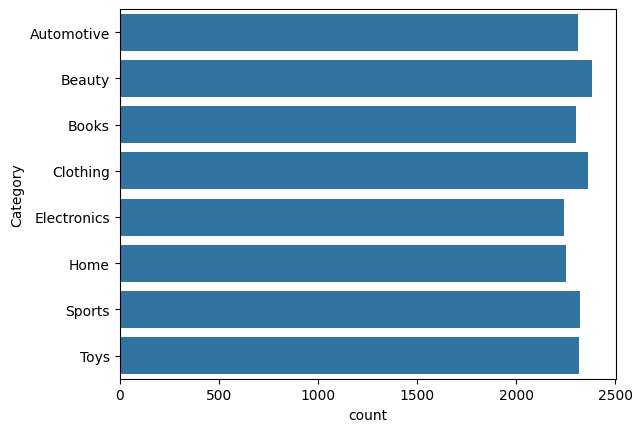

In [275]:
sns.countplot(train_df['Category'])
plt.show()

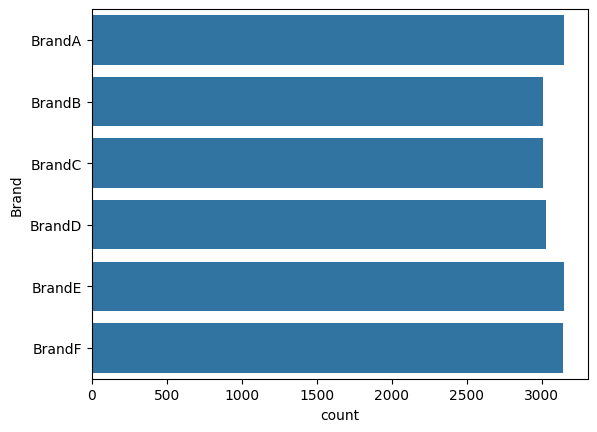

In [276]:
sns.countplot(train_df['Brand'])
plt.show()

In [277]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [278]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity,price_diff,is_discounted,year,month,day_of_month,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end
0,2024-09-26,Automotive,BrandA,3,0,17.9,462.30,33.96,359.45,227.0,102.85,1,2024,9,26,0,0,0,0,0,0,0
1,2024-09-26,Automotive,BrandA,3,0,66.3,321.28,24.76,49.47,370.0,271.81,1,2024,9,26,0,0,0,0,0,0,0
2,2024-09-26,Automotive,BrandA,3,0,14.4,74.85,32.19,245.11,299.0,-170.26,0,2024,9,26,0,0,0,0,0,0,0
3,2024-09-26,Automotive,BrandA,3,0,34.7,469.12,43.68,144.08,426.0,325.04,1,2024,9,26,0,0,0,0,0,0,0
4,2024-09-22,Automotive,BrandA,6,1,93.5,221.76,36.79,478.07,470.0,-256.31,0,2024,9,22,1,0,0,0,0,0,0


In [279]:
train_df['Holiday_Indicator'].value_counts(normalize=True) * 100

Holiday_Indicator
0    85.79776
1    14.20224
Name: proportion, dtype: float64

In [280]:
train_df['is_weekend'].value_counts(normalize=True) * 100

is_weekend
0    70.73527
1    29.26473
Name: proportion, dtype: float64

In [281]:
train_df['Discount_percentage'] = (train_df['Discount'] / train_df['Price']) * 100

In [282]:
train_df['Discount_percentage'].describe()

count    18483.000000
mean        14.026954
std         13.008440
min          1.012952
25%          5.868893
50%         10.016913
75%         17.068065
max         97.705882
Name: Discount_percentage, dtype: float64

In [283]:
train_df['Discount_percentage_binned'] = pd.cut(train_df['Discount_percentage'], bins=[0, 25, 50, 75, 100], labels=['0-25', '25-50', '50-75', '75-100'])

In [284]:
train_df['Discount_percentage_binned'].value_counts(normalize=True) * 100

Discount_percentage_binned
0-25      86.079100
25-50     11.004707
50-75      2.450901
75-100     0.465292
Name: proportion, dtype: float64

In [285]:
test_df['Discount_percentage'] = (test_df['Discount'] / test_df['Price']) * 100

In [286]:
test_df['Discount_percentage_binned'] = pd.cut(test_df['Discount_percentage'], bins=[0, 25, 50, 75, 100], labels=['0-25', '25-50', '50-75', '75-100'])

In [287]:
test_df['Discount_percentage_binned'].value_counts(normalize=True) * 100

Discount_percentage_binned
0-25      86.787072
25-50     11.121673
50-75      1.615970
75-100     0.475285
Name: proportion, dtype: float64

In [288]:
train_df['Final_Price'] = train_df['Price'] - train_df['Discount']

In [289]:
test_df['Final_Price'] = test_df['Price'] - test_df['Discount']

In [290]:
train_df['price_diff_final'] = train_df['Final_Price'] - train_df['Competitor_Price']

In [291]:
train_df['is_discounted_final'] = np.where(train_df['price_diff_final'] > 0, 1, 0)

In [292]:
train_df['is_discounted_final'].value_counts(normalize=True) * 100

is_discounted_final
0    52.832332
1    47.167668
Name: proportion, dtype: float64

In [293]:
train_df['is_discounted'].value_counts(normalize=True) * 100

is_discounted
1    53.146134
0    46.853866
Name: proportion, dtype: float64

In [294]:
test_df['price_diff_final'] = test_df['Final_Price'] - test_df['Competitor_Price']

In [295]:
test_df['is_discounted_final'] = np.where(test_df['price_diff_final'] > 0, 1, 0)

In [296]:
test_df['is_discounted_final'].value_counts(normalize=True) * 100

is_discounted_final
0    52.851711
1    47.148289
Name: proportion, dtype: float64

In [297]:
train_df['average_category_brand_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform('mean')
train_df['median_category_brand_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform('median')
train_df['std_category_brand_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform('std')
train_df['min_category_brand_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform('min')
train_df['max_category_brand_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform('max')

In [298]:
test_df['average_category_brand_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform('mean')
test_df['median_category_brand_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform('median')
test_df['std_category_brand_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform('std')
test_df['min_category_brand_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform('min')
test_df['max_category_brand_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform('max')

In [299]:
train_df['mean_discount_category_brand'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('mean')
train_df['median_discount_category_brand'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('median')
train_df['std_discount_category_brand'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('std')
train_df['min_discount_category_brand'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('min')
train_df['max_discount_category_brand'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('max')

In [300]:
test_df['mean_discount_category_brand'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('mean')
test_df['median_discount_category_brand'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('median')
test_df['std_discount_category_brand'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('std')
test_df['min_discount_category_brand'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('min')
test_df['max_discount_category_brand'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform('max')

In [301]:
train_df['mode_discount_category_brand_binned'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage_binned'].transform(lambda x: x.mode().iloc[0])

In [302]:
test_df['mode_discount_category_brand_binned'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage_binned'].transform(lambda x: x.mode().iloc[0])

In [303]:
train_df = train_df.sort_values(by='Date').reset_index(drop=True)
test_df = test_df.sort_values(by='Date').reset_index(drop=True)

In [304]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity,price_diff,is_discounted,year,month,day_of_month,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,Discount_percentage,Discount_percentage_binned,Final_Price,price_diff_final,is_discounted_final,average_category_brand_price,median_category_brand_price,std_category_brand_price,min_category_brand_price,max_category_brand_price,mean_discount_category_brand,median_discount_category_brand,std_discount_category_brand,min_discount_category_brand,max_discount_category_brand,mode_discount_category_brand_binned
0,2021-01-05,Sports,BrandB,5,0,24.4,457.87,38.11,136.19,451.0,321.68,1,2021,1,5,0,0,0,0,0,0,0,8.323323,0-25,419.76,283.57,1,276.098769,271.27,126.148004,50.81,499.04,13.913844,10.134601,12.124117,1.132174,64.155713,0-25
1,2021-01-05,Sports,BrandC,5,0,59.1,98.34,12.54,70.34,125.0,28.00,1,2021,1,5,0,0,0,0,0,0,0,12.751678,0-25,85.80,15.46,1,269.723379,277.00,128.622407,50.40,498.95,14.923485,10.312485,14.195489,1.425318,92.046784,0-25
2,2021-01-05,Beauty,BrandE,5,0,54.9,262.91,42.77,173.73,483.0,89.18,1,2021,1,5,0,0,0,0,0,0,0,16.267924,0-25,220.14,46.41,1,276.753176,283.27,125.827285,51.09,498.41,13.471023,9.120687,12.500538,1.415988,89.315431,0-25
3,2021-01-05,Home,BrandC,5,0,79.6,342.60,35.44,443.02,209.0,-100.42,0,2021,1,5,0,0,0,0,0,0,0,10.344425,0-25,307.16,-135.86,0,276.716911,277.00,134.740078,51.55,499.25,14.109541,9.272924,13.063634,1.100457,88.826382,0-25
4,2021-01-05,Beauty,BrandA,5,0,36.7,271.56,18.94,349.97,388.0,-78.41,0,2021,1,5,0,0,0,0,0,0,0,6.974518,0-25,252.62,-97.35,0,270.563437,270.84,129.889578,50.13,497.38,13.959668,9.855248,13.780291,1.087201,92.837993,0-25


In [305]:
train_df['rolling_week_avg_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(7).mean())
train_df['rolling_week_avg_discount'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(7).mean())

In [306]:
test_df['rolling_week_avg_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(7).mean())
test_df['rolling_week_avg_discount'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(7).mean())

In [307]:
train_df['rolling_month_avg_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(30).mean())
train_df['rolling_month_avg_discount'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(30).mean())

In [308]:
test_df['rolling_month_avg_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(30).mean())
test_df['rolling_month_avg_discount'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(30).mean())

In [309]:
train_df['rolling_quarter_avg_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(90).mean())
train_df['rolling_quarter_avg_discount'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(90).mean())

In [310]:
test_df['rolling_quarter_avg_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(90).mean())
test_df['rolling_quarter_avg_discount'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(90).mean())

In [311]:
train_df['rolling_year_avg_price'] = train_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(365).mean())
train_df['rolling_year_avg_discount'] = train_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(365).mean())

In [312]:
test_df['rolling_year_avg_price'] = test_df.groupby(['Category', 'Brand'])['Price'].transform(lambda x: x.rolling(365).mean())
test_df['rolling_year_avg_discount'] = test_df.groupby(['Category', 'Brand'])['Discount_percentage'].transform(lambda x: x.rolling(365).mean())

In [463]:
train_df['rolling_week_avg_Past_Purchase_Trends'] = train_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(7).mean())
train_df['rolling_month_avg_Past_Purchase_Trends'] = train_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(30).mean())
train_df['rolling_quarter_avg_Past_Purchase_Trends'] = train_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(90).mean())
train_df['rolling_year_avg_Past_Purchase_Trends'] = train_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(365).mean())

In [464]:
test_df['rolling_week_avg_Past_Purchase_Trends'] = test_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(7).mean())
test_df['rolling_month_avg_Past_Purchase_Trends'] = test_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(30).mean())
test_df['rolling_quarter_avg_Past_Purchase_Trends'] = test_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(90).mean())
test_df['rolling_year_avg_Past_Purchase_Trends'] = test_df.groupby(['Category', 'Brand'])['Past_Purchase_Trends'].transform(lambda x: x.rolling(365).mean())

In [313]:
train_df['year'].value_counts(normalize=True) * 100

year
2022    27.078937
2023    26.873343
2021    25.888654
2024    20.159065
Name: proportion, dtype: float64

In [314]:
train_df['is_leap_year'] = train_df['Date'].dt.is_leap_year
test_df['is_leap_year'] = test_df['Date'].dt.is_leap_year

In [315]:
train_df['is_leap_year'].value_counts(normalize=True) * 100

is_leap_year
False    79.840935
True     20.159065
Name: proportion, dtype: float64

In [316]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity,price_diff,is_discounted,year,month,day_of_month,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,Discount_percentage,Discount_percentage_binned,Final_Price,price_diff_final,is_discounted_final,average_category_brand_price,median_category_brand_price,std_category_brand_price,min_category_brand_price,max_category_brand_price,mean_discount_category_brand,median_discount_category_brand,std_discount_category_brand,min_discount_category_brand,max_discount_category_brand,mode_discount_category_brand_binned,rolling_week_avg_price,rolling_week_avg_discount,rolling_month_avg_price,rolling_month_avg_discount,rolling_quarter_avg_price,rolling_quarter_avg_discount,rolling_year_avg_price,rolling_year_avg_discount,is_leap_year
0,2021-01-05,Sports,BrandB,5,0,24.4,457.87,38.11,136.19,451.0,321.68,1,2021,1,5,0,0,0,0,0,0,0,8.323323,0-25,419.76,283.57,1,276.098769,271.27,126.148004,50.81,499.04,13.913844,10.134601,12.124117,1.132174,64.155713,0-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2021-01-05,Sports,BrandC,5,0,59.1,98.34,12.54,70.34,125.0,28.00,1,2021,1,5,0,0,0,0,0,0,0,12.751678,0-25,85.80,15.46,1,269.723379,277.00,128.622407,50.40,498.95,14.923485,10.312485,14.195489,1.425318,92.046784,0-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2021-01-05,Beauty,BrandE,5,0,54.9,262.91,42.77,173.73,483.0,89.18,1,2021,1,5,0,0,0,0,0,0,0,16.267924,0-25,220.14,46.41,1,276.753176,283.27,125.827285,51.09,498.41,13.471023,9.120687,12.500538,1.415988,89.315431,0-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2021-01-05,Home,BrandC,5,0,79.6,342.60,35.44,443.02,209.0,-100.42,0,2021,1,5,0,0,0,0,0,0,0,10.344425,0-25,307.16,-135.86,0,276.716911,277.00,134.740078,51.55,499.25,14.109541,9.272924,13.063634,1.100457,88.826382,0-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2021-01-05,Beauty,BrandA,5,0,36.7,271.56,18.94,349.97,388.0,-78.41,0,2021,1,5,0,0,0,0,0,0,0,6.974518,0-25,252.62,-97.35,0,270.563437,270.84,129.889578,50.13,497.38,13.959668,9.855248,13.780291,1.087201,92.837993,0-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [317]:
train_df['mean_sales_category_brand'] = train_df.groupby(['Category', 'Brand'])['Sales_Quantity'].transform('mean')
train_df['median_sales_category_brand'] = train_df.groupby(['Category', 'Brand'])['Sales_Quantity'].transform('median')
train_df['std_sales_category_brand'] = train_df.groupby(['Category', 'Brand'])['Sales_Quantity'].transform('std')
train_df['min_sales_category_brand'] = train_df.groupby(['Category', 'Brand'])['Sales_Quantity'].transform('min')
train_df['max_sales_category_brand'] = train_df.groupby(['Category', 'Brand'])['Sales_Quantity'].transform('max')

In [318]:
from tqdm import tqdm
tqdm.pandas()

In [319]:
for i, group in tqdm(test_df.groupby(['Category', 'Brand'])):
    train_group = train_df[(train_df['Category'] == i[0]) & (train_df['Brand'] == i[1])]
    test_df.loc[group.index, 'mean_sales_category_brand'] = train_group['Sales_Quantity'].mean()
    test_df.loc[group.index, 'median_sales_category_brand'] = train_group['Sales_Quantity'].median()
    test_df.loc[group.index, 'std_sales_category_brand'] = train_group['Sales_Quantity'].std()
    test_df.loc[group.index, 'min_sales_category_brand'] = train_group['Sales_Quantity'].min()
    test_df.loc[group.index, 'max_sales_category_brand'] = train_group['Sales_Quantity'].max()

100%|██████████| 48/48 [00:00<00:00, 232.93it/s]


In [320]:
train_df.isna().mean()[train_df.isna().mean() > 0]

Sales_Quantity                  0.025104
rolling_week_avg_price          0.015582
rolling_week_avg_discount       0.015582
rolling_month_avg_price         0.075312
rolling_month_avg_discount      0.075312
rolling_quarter_avg_price       0.231131
rolling_quarter_avg_discount    0.231131
rolling_year_avg_price          0.942434
rolling_year_avg_discount       0.942434
dtype: float64

In [321]:
train_df.dropna(subset=['Sales_Quantity'], inplace=True)

In [322]:
test_df.isna().mean()[test_df.isna().mean() > 0]

Sales_Quantity                  1.000000
rolling_week_avg_price          0.273764
rolling_week_avg_discount       0.273764
rolling_month_avg_price         0.986692
rolling_month_avg_discount      0.986692
rolling_quarter_avg_price       1.000000
rolling_quarter_avg_discount    1.000000
rolling_year_avg_price          1.000000
rolling_year_avg_discount       1.000000
dtype: float64

In [323]:
train_df.dtypes

Date                                   datetime64[ns]
Category                                       object
Brand                                          object
Day_of_Week                                     int64
Holiday_Indicator                               int64
Past_Purchase_Trends                          float64
Price                                         float64
Discount                                      float64
Competitor_Price                              float64
Sales_Quantity                                float64
price_diff                                    float64
is_discounted                                   int64
year                                            int32
month                                           int32
day_of_month                                    int32
is_weekend                                      int64
is_month_start                                  int64
is_month_end                                    int64
is_quarter_start            

In [324]:
correlation = train_df.select_dtypes(exclude=['category', 'object']).corr()

In [325]:
correlation['Sales_Quantity'].sort_values(ascending=False)

Sales_Quantity                    1.000000
mean_sales_category_brand         0.050719
median_sales_category_brand       0.044671
rolling_year_avg_discount         0.024714
max_category_brand_price          0.019934
mean_discount_category_brand      0.018915
rolling_quarter_avg_discount      0.015657
rolling_month_avg_discount        0.013722
std_discount_category_brand       0.012196
rolling_year_avg_price            0.008781
min_category_brand_price          0.008694
median_discount_category_brand    0.008231
min_discount_category_brand       0.007728
rolling_week_avg_price            0.005933
min_sales_category_brand          0.005230
month                             0.002680
Competitor_Price                  0.002003
Date                              0.001174
Discount                          0.001037
is_quarter_start                  0.000839
is_weekend                        0.000726
year                              0.000710
is_leap_year                      0.000618
is_month_en

In [326]:
bool_cols = train_df.select_dtypes(include=['bool']).columns

In [327]:
len(bool_cols)

1

In [328]:
for col in bool_cols:
    train_df[col] = train_df[col].astype('int')
    test_df[col] = test_df[col].astype('int')

In [329]:
test_bool_cols = test_df.select_dtypes(include=['bool']).columns

In [330]:
len(test_bool_cols)

0

In [331]:
cat_cols = ['Category', 'Brand', 'Discount_percentage_binned', 'mode_discount_category_brand_binned']

In [332]:
for col in cat_cols:
    train_df[col] = train_df[col].astype('category')
    test_df[col] = test_df[col].astype('category')

In [333]:
for col in cat_cols:
    train_df[col] = train_df[col].cat.codes
    test_df[col] = test_df[col].cat.codes

In [334]:
train_df.head()

,Date,Category,Brand,Day_of_Week,Holiday_Indicator,Past_Purchase_Trends,Price,Discount,Competitor_Price,Sales_Quantity,price_diff,is_discounted,year,month,day_of_month,is_weekend,is_month_start,is_month_end,is_quarter_start,is_quarter_end,is_year_start,is_year_end,Discount_percentage,Discount_percentage_binned,Final_Price,price_diff_final,is_discounted_final,average_category_brand_price,median_category_brand_price,std_category_brand_price,min_category_brand_price,max_category_brand_price,mean_discount_category_brand,median_discount_category_brand,std_discount_category_brand,min_discount_category_brand,max_discount_category_brand,mode_discount_category_brand_binned,rolling_week_avg_price,rolling_week_avg_discount,rolling_month_avg_price,rolling_month_avg_discount,rolling_quarter_avg_price,rolling_quarter_avg_discount,rolling_year_avg_price,rolling_year_avg_discount,is_leap_year,mean_sales_category_brand,median_sales_category_brand,std_sales_category_brand,min_sales_category_brand,max_sales_category_brand
0,2021-01-05,6,1,5,0,24.4,457.87,38.11,136.19,451.0,321.68,1,2021,1,5,0,0,0,0,0,0,0,8.323323,0,419.76,283.57,1,276.098769,271.27,126.148004,50.81,499.04,13.913844,10.134601,12.124117,1.132174,64.155713,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,262.185864,272.0,143.005679,11.0,497.0
1,2021-01-05,6,2,5,0,59.1,98.34,12.54,70.34,125.0,28.00,1,2021,1,5,0,0,0,0,0,0,0,12.751678,0,85.80,15.46,1,269.723379,277.00,128.622407,50.40,498.95,14.923485,10.312485,14.195489,1.425318,92.046784,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,264.406250,267.5,142.038806,10.0,499.0
2,2021-01-05,1,4,5,0,54.9,262.91,42.77,173.73,483.0,89.18,1,2021,1,5,0,0,0,0,0,0,0,16.267924,0,220.14,46.41,1,276.753176,283.27,125.827285,51.09,498.41,13.471023,9.120687,12.500538,1.415988,89.315431,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,260.310843,259.0,141.321394,10.0,499.0
3,2021-01-05,5,2,5,0,79.6,342.60,35.44,443.02,209.0,-100.42,0,2021,1,5,0,0,0,0,0,0,0,10.344425,0,307.16,-135.86,0,276.716911,277.00,134.740078,51.55,499.25,14.109541,9.272924,13.063634,1.100457,88.826382,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,258.115702,264.0,141.920287,10.0,499.0
4,2021-01-05,1,0,5,0,36.7,271.56,18.94,349.97,388.0,-78.41,0,2021,1,5,0,0,0,0,0,0,0,6.974518,0,252.62,-97.35,0,270.563437,270.84,129.889578,50.13,497.38,13.959668,9.855248,13.780291,1.087201,92.837993,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,242.777487,225.0,142.563096,11.0,499.0


In [335]:
import lightgbm as lgb

In [465]:
train = train_df.loc[:int(len(train_df) * 0.8)]
valid = train_df.loc[int(len(train_df) * 0.8):]

In [466]:
train.shape, valid.shape

((14058, 56), (3962, 56))

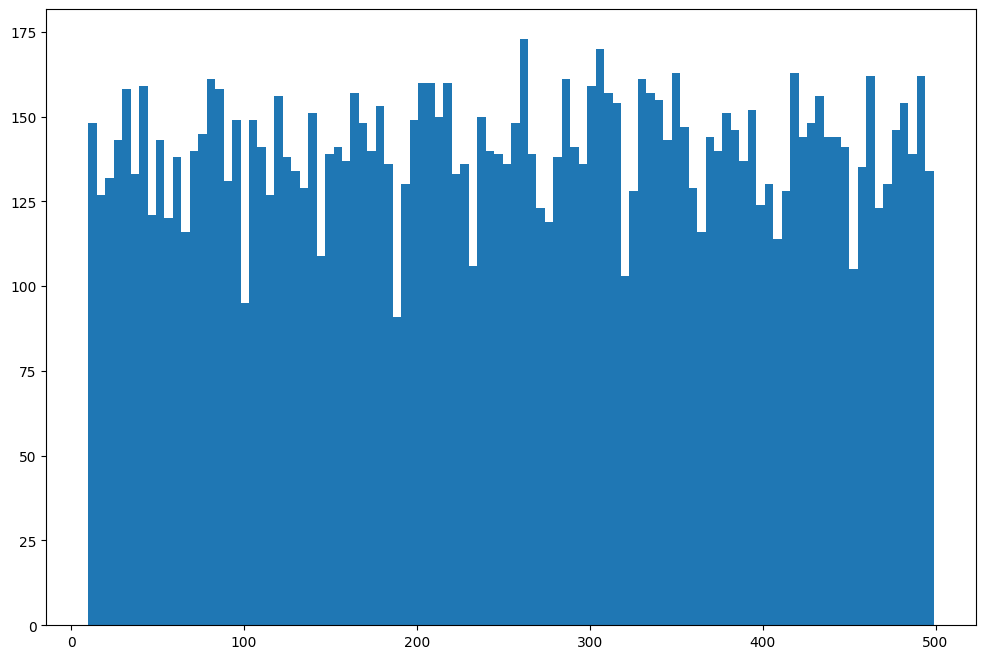

In [467]:
plt.figure(figsize=(12, 8))
plt.hist(train['Sales_Quantity'], bins=100)
plt.show()

In [468]:
multi_collinearity = correlation[(correlation > 0.9) & (correlation < 1)].stack().dropna()

In [469]:
multi_collinearity

Date                          year                            0.966221
Price                         Final_Price                     0.994999
price_diff                    price_diff_final                0.997404
year                          Date                            0.966221
Final_Price                   Price                           0.994999
price_diff_final              price_diff                      0.997404
average_category_brand_price  rolling_year_avg_price          0.962830
mean_discount_category_brand  rolling_year_avg_discount       0.942865
rolling_year_avg_price        average_category_brand_price    0.962830
rolling_year_avg_discount     mean_discount_category_brand    0.942865
dtype: float64

In [470]:
lgb_train = lgb.Dataset(train.drop(columns=['Date', 'Sales_Quantity']), label=train['Sales_Quantity'], categorical_feature=cat_cols, free_raw_data=False)
lgb_valid = lgb.Dataset(valid.drop(columns=['Date', 'Sales_Quantity']), label=valid['Sales_Quantity'], categorical_feature=cat_cols, reference=lgb_train, free_raw_data=False)

In [471]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 200,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 1,
    'max_depth': 12,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
}

In [472]:
lgb_model = lgb.train(lgb_params, lgb_train, valid_sets=[lgb_valid], num_boost_round=600)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5051
[LightGBM] [Info] Number of data points in the train set: 14058, number of used features: 48
[LightGBM] [Info] Start training from score 255.686584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [473]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [474]:
valid_preds = lgb_model.predict(valid.drop(columns=['Date', 'Sales_Quantity']))

In [475]:
train_preds = lgb_model.predict(train.drop(columns=['Date', 'Sales_Quantity']))

In [476]:
mean_squared_error(valid['Sales_Quantity'], valid_preds, squared=False)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


147.94250888795813

In [477]:
mean_squared_error(train['Sales_Quantity'], train_preds, squared=False)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


22.333283304019023

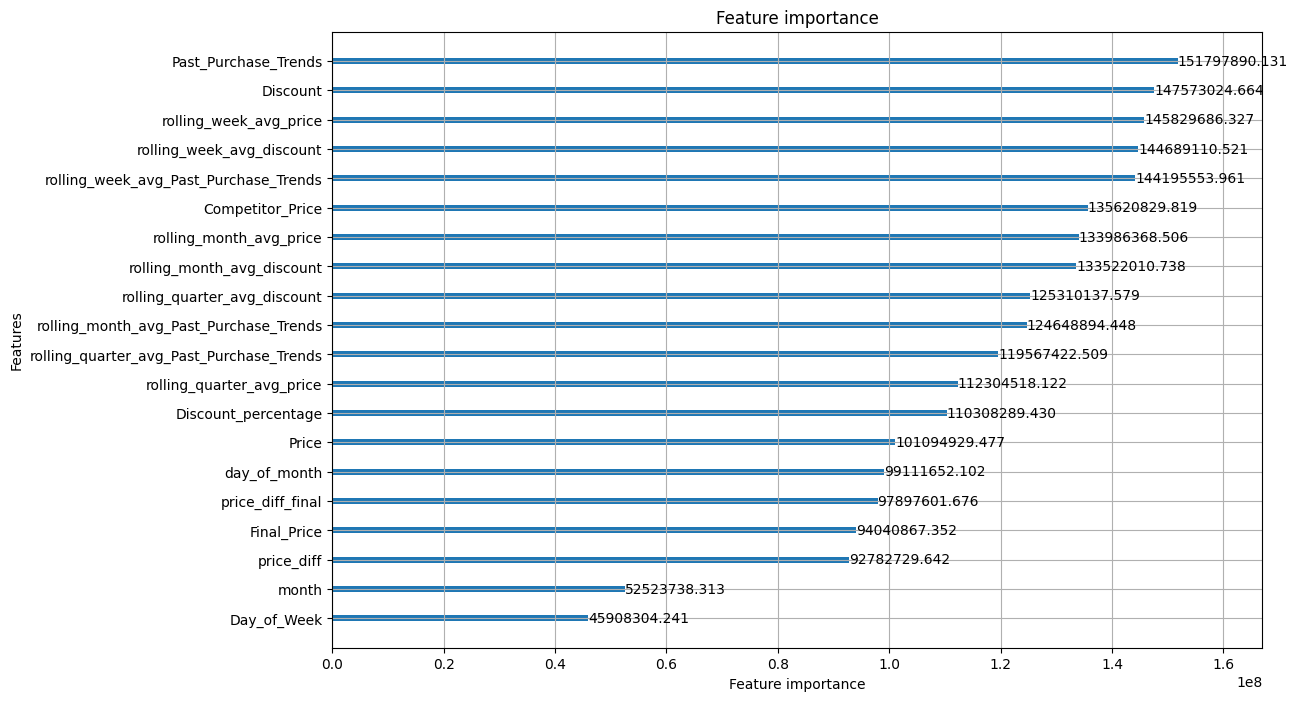

In [478]:
lgb.plot_importance(lgb_model, importance_type='gain', figsize=(12, 8), max_num_features=20)
plt.show()

In [479]:
top_features = lgb_model.feature_importance(importance_type='gain')

In [480]:
top_features_df = pd.DataFrame(top_features, index=lgb_model.feature_name(), columns=['importance']).sort_values(by='importance', ascending=False)

In [481]:
top_features_df.head(20)

,importance
Past_Purchase_Trends,1.517979e+08
Discount,1.475730e+08
rolling_week_avg_price,1.458297e+08
rolling_week_avg_discount,1.446891e+08
rolling_week_avg_Past_Purchase_Trends,1.441956e+08
Competitor_Price,1.356208e+08
rolling_month_avg_price,1.339864e+08
rolling_month_avg_discount,1.335220e+08
rolling_quarter_avg_discount,1.253101e+08
rolling_month_avg_Past_Purchase_Trends,1.246489e+08


In [482]:
top_features_df['normalized_importance'] = top_features_df['importance'] / top_features_df['importance'].sum()

In [483]:
top_features_df['cumulative_importance'] = top_features_df['normalized_importance'].cumsum()

In [484]:
top_features_df = top_features_df.reset_index(names='feature')

In [485]:
top_features_df.loc[top_features_df['cumulative_importance'] <= 0.95, 'feature']

0                         Past_Purchase_Trends
1                                     Discount
2                       rolling_week_avg_price
3                    rolling_week_avg_discount
4        rolling_week_avg_Past_Purchase_Trends
5                             Competitor_Price
6                      rolling_month_avg_price
7                   rolling_month_avg_discount
8                 rolling_quarter_avg_discount
9       rolling_month_avg_Past_Purchase_Trends
10    rolling_quarter_avg_Past_Purchase_Trends
11                   rolling_quarter_avg_price
12                         Discount_percentage
13                                       Price
14                                day_of_month
15                            price_diff_final
16                                 Final_Price
17                                  price_diff
18                                       month
19                                 Day_of_Week
20                 min_discount_category_brand
21           

In [486]:
selected_features = top_features_df.loc[top_features_df['cumulative_importance'] <= 0.95, 'feature']

In [487]:
len(selected_features)

31

In [490]:
selected_features

0                         Past_Purchase_Trends
1                                     Discount
2                       rolling_week_avg_price
3                    rolling_week_avg_discount
4        rolling_week_avg_Past_Purchase_Trends
5                             Competitor_Price
6                      rolling_month_avg_price
7                   rolling_month_avg_discount
8                 rolling_quarter_avg_discount
9       rolling_month_avg_Past_Purchase_Trends
10    rolling_quarter_avg_Past_Purchase_Trends
11                   rolling_quarter_avg_price
12                         Discount_percentage
13                                       Price
14                                day_of_month
15                            price_diff_final
16                                 Final_Price
17                                  price_diff
18                                       month
19                                 Day_of_Week
20                 min_discount_category_brand
21           

In [488]:
selected_cat_cols = [col for col in selected_features if col in cat_cols]

In [489]:
selected_cat_cols

[]

In [491]:
lgb_train_full = lgb.Dataset(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features], label=train_df['Sales_Quantity'])
lgb_test = lgb.Dataset(test_df.drop(columns=['Date'])[selected_features], categorical_feature=selected_cat_cols)

In [492]:
lgb_params_full = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 200,
    'feature_fraction':1,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 1,
    'max_depth': 12,
    'reg_alpha': 0.5,
    'reg_lambda': 0.5,
}

In [493]:
lgb_model_full = lgb.train(lgb_params_full, lgb_train_full, num_boost_round=700)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4913
[LightGBM] [Info] Number of data points in the train set: 18019, number of used features: 31
[LightGBM] [Info] Start training from score 255.665631
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [494]:
test_preds = lgb_model_full.predict(test_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

In [495]:
test_df['Sales_Quantity'] = test_preds

In [496]:
min(test_preds), max(test_preds)

(95.585208263785, 395.62148524696494)

In [497]:
min(train_df['Sales_Quantity']), max(train_df['Sales_Quantity'])

(10.0, 499.0)

In [498]:
test_df['Sales_Quantity'] = test_df['Sales_Quantity'].round()

In [499]:
min(test_df['Sales_Quantity']), max(test_df['Sales_Quantity'])

(96.0, 396.0)

In [500]:
submission = test_df['Sales_Quantity']

In [501]:
submission.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/submission_new.csv", index=False)

In [502]:
test_df.shape

(1052, 56)

In [503]:
import xgboost as xgb

In [504]:
xgb_train = xgb.DMatrix(train.drop(columns=['Date', 'Sales_Quantity'])[selected_features], label=train['Sales_Quantity'])
xgb_valid = xgb.DMatrix(valid.drop(columns=['Date', 'Sales_Quantity'])[selected_features], label=valid['Sales_Quantity'])

In [505]:
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.01,
    'max_depth': 20,
    'subsample': 0.8,
    'colsample_bytree': 1,
    'alpha': 0.5,
    'lambda': 1,
}

In [506]:
xgb_model = xgb.train(xgb_params, xgb_train, num_boost_round=700, evals=[(xgb_train, 'train'),(xgb_valid, 'valid')], early_stopping_rounds=50, verbose_eval=10)

[0]	train-rmse:139.99311	valid-rmse:142.67818
[10]	train-rmse:132.67256	valid-rmse:142.75770
[20]	train-rmse:125.63842	valid-rmse:142.76010
[30]	train-rmse:119.02660	valid-rmse:142.77122
[40]	train-rmse:112.97465	valid-rmse:142.76853
[50]	train-rmse:107.62856	valid-rmse:142.86713
[51]	train-rmse:107.05452	valid-rmse:142.88241


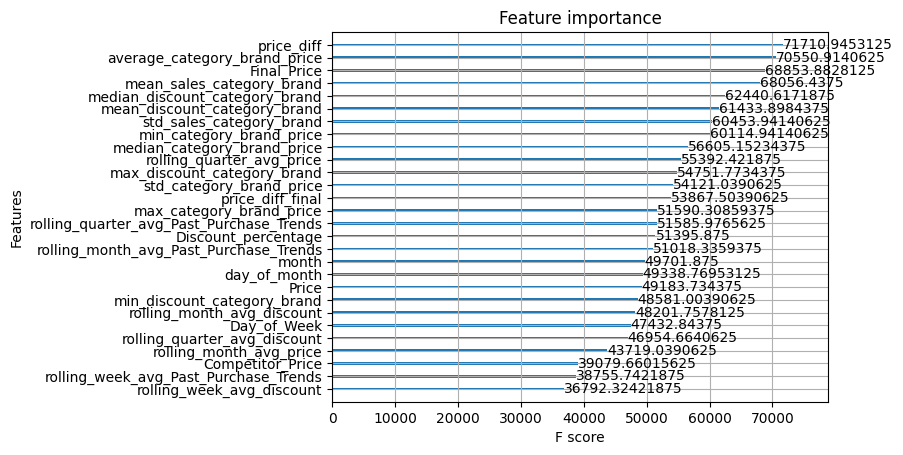

In [507]:
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=28)
plt.show()

In [508]:
xgb_test = xgb.DMatrix(test_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

In [509]:
xgb_train_full = xgb.DMatrix(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features], label=train_df['Sales_Quantity'])

In [510]:
xgb_params_full = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.01,
    'max_depth': 15,
    'subsample': 0.8,
    'colsample_bytree': 1,
    'alpha': 0.5,
    'lambda': 1,
}

In [546]:
xgb_model_full = xgb.train(xgb_params_full, xgb_train_full, num_boost_round=700)

In [547]:
test_preds_xgb = xgb_model_full.predict(xgb_test)

In [548]:
test_df['Sales_Quantity'] = test_preds_xgb

In [549]:
test_df['Sales_Quantity'] = test_df['Sales_Quantity'].round()

In [550]:
min(test_df['Sales_Quantity']), max(test_df['Sales_Quantity'])

(177.0, 352.0)

In [551]:
submission_xgb = test_df['Sales_Quantity']

In [552]:
submission_xgb.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/submission_xgb.csv", index=False)

In [518]:
from sklearn.ensemble import RandomForestRegressor, VotingRegressor

In [519]:
import catboost as cb

In [533]:
cb_params = {
    'objective': 'RMSE',
    'learning_rate': 0.05,
    'depth': 10,
    'l2_leaf_reg': 1,
    'verbose': 0,
}

In [556]:
cb_model = cb.CatBoostRegressor(**cb_params, iterations=300)

In [557]:
lgb_model_full = lgb.LGBMRegressor(**lgb_params_full, num_boost_round=300)

In [558]:
xgb_model_full = xgb.XGBRegressor(**xgb_params_full, n_estimators=300)

In [537]:
vr = VotingRegressor(estimators=[('lgb', lgb_model_full), ('xgb', xgb_model_full), ('cb', cb_model)])

In [538]:
vr.fit(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features], train_df['Sales_Quantity'])

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


[LightGBM] [Warning] num_iterations is set=300, num_boost_round=300 will be ignored. Current value: num_iterations=300
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 

VotingRegressor(estimators=[('lgb',
                             LGBMRegressor(bagging_fraction=0.8, bagging_freq=5,
                                           feature_fraction=1,
                                           learning_rate=0.05, max_depth=12,
                                           metric='rmse', num_boost_round=300,
                                           num_leaves=200,
                                           objective='regression',
                                           reg_alpha=0.5, reg_lambda=0.5,
                                           verbose=1)),
                            ('xgb',
                             XGBRegressor(alpha=0.5, base_score=None,
                                          booster=None, callbacks=None,
                                          colsample_bylevel=None,
                                          cols...
                                          importance_type=None,
                                          interaction_constraints=None,
                                          lambda=1, learning_rate=None,
                                          max_bin=None, max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=15,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=300, ...)),
                            ('cb',
                             <catboost.core.CatBoostRegressor object at 0x33925f9d0>)])

In [539]:
train_preds_vr = vr.predict(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [540]:
mean_squared_error(train_df['Sales_Quantity'], np.floor(train_preds_vr), squared=False)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


70.41323366541691

In [541]:
test_preds = vr.predict(test_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [542]:
min(test_preds), max(test_preds)

(188.15582045864628, 325.9446429909767)

In [543]:
test_df['Sales_Quantity'] = np.floor(test_preds)

In [544]:
submission_vr = test_df['Sales_Quantity']

In [545]:
submission_vr.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/submission_vr.csv", index=False)

In [553]:
from sklearn.ensemble import StackingRegressor

In [561]:
stack = StackingRegressor(estimators=[('lgb', lgb_model_full), ('xgb', xgb_model_full), ('cb', cb_model)], final_estimator=xgb_model_full)

In [562]:
stack.fit(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features], train_df['Sales_Quantity'])

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


[LightGBM] [Warning] num_iterations is set=300, num_boost_round=300 will be ignored. Current value: num_iterations=300
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


[LightGBM] [Warning] num_iterations is set=300, num_boost_round=300 will be ignored. Current value: num_iterations=300
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


...

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/lightgbm/engine.py:204: UserWarning: Found `num_boost_round` in params. Will use it instead of argument
  )


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

StackingRegressor(estimators=[('lgb',
                               LGBMRegressor(bagging_fraction=0.8,
                                             bagging_freq=5, feature_fraction=1,
                                             learning_rate=0.05, max_depth=12,
                                             metric='rmse', num_boost_round=300,
                                             num_leaves=200,
                                             objective='regression',
                                             reg_alpha=0.5, reg_lambda=0.5,
                                             verbose=1)),
                              ('xgb',
                               XGBRegressor(alpha=0.5, base_score=None,
                                            booster=None, callbacks=None,
                                            colsample_bylevel=None,
                                            co...
                                               eta=0.01, eval_metric='rmse',
                                               feature_types=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               lambda=1, learning_rate=None,
                                               max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None,
                                               max_depth=15, max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, ...))

In [563]:
train_preds = stack.predict(train_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [564]:
mean_squared_error(train_df['Sales_Quantity'], np.floor(train_preds), squared=False)

/Users/priyanshu.tuli/Desktop/machinehack/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


147.8376357201502

In [565]:
test_preds = stack.predict(test_df.drop(columns=['Date', 'Sales_Quantity'])[selected_features])

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=1, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=1
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


In [567]:
test_preds = np.floor(test_preds)

In [568]:
min(test_preds), max(test_preds)

(134.0, 380.0)

In [569]:
test_df['Sales_Quantity'] = test_preds

In [570]:
submission_stack = test_df['Sales_Quantity']

In [571]:
submission_stack.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/submission_stack.csv", index=False)

In [572]:
from sklearn.cluster import KMeans

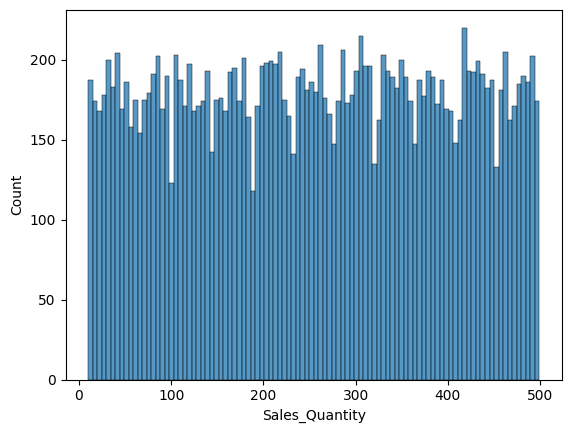

In [573]:
sns.histplot(train_df['Sales_Quantity'], bins=100)
plt.show()

In [574]:
kmean = KMeans(n_clusters=100)

In [575]:
kmean.fit(train_df['Sales_Quantity'].values.reshape(-1, 1))

KMeans(n_clusters=100)

In [576]:
train_df['cluster'] = kmean.predict(train_df['Sales_Quantity'].values.reshape(-1, 1))

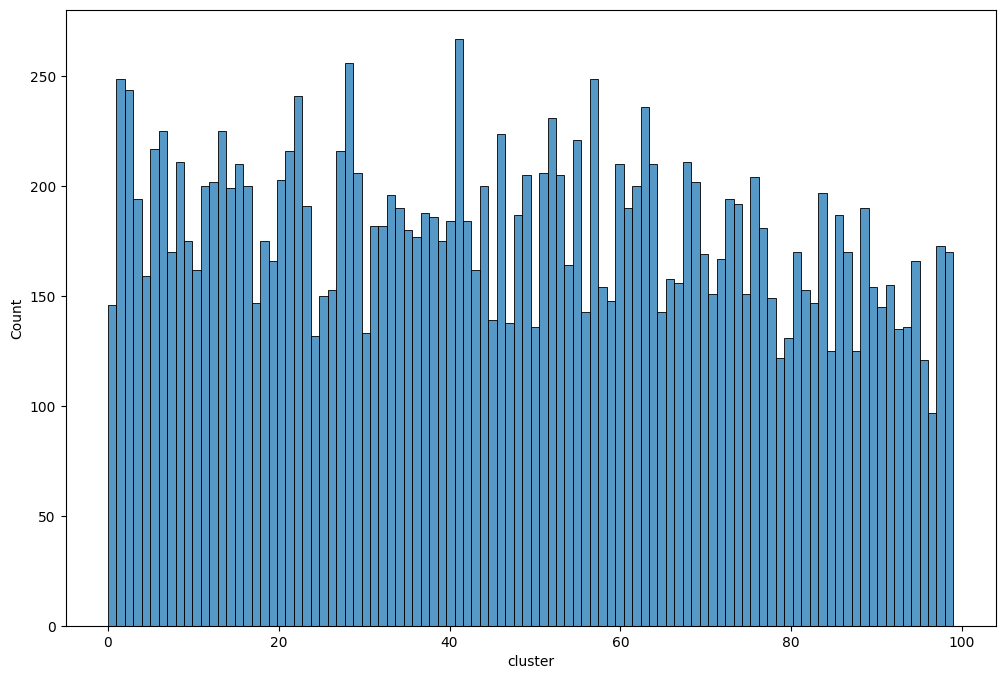

In [579]:
plt.figure(figsize=(12, 8))
sns.histplot(train_df['cluster'], bins=100)
plt.show()

In [581]:
train = train_df.loc[:int(len(train_df) * 0.8)]
valid = train_df.loc[int(len(train_df) * 0.8):]

In [582]:
xgb_train = xgb.DMatrix(train.drop(columns=['Date', 'Sales_Quantity', 'cluster']), label=train['cluster'])
xgb_valid = xgb.DMatrix(valid.drop(columns=['Date', 'Sales_Quantity', 'cluster']), label=valid['cluster'])

In [587]:
xgb_cluster_params = {
    'objective': 'multi:softmax',
    'eval_metric': 'mlogloss',
    'eta': 0.05,
    'max_depth': 15,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'alpha': 0.5,
    'lambda': 1,
    'num_class': 100,
}

In [589]:
xgb_cluster_model = xgb.train(xgb_cluster_params, xgb_train, num_boost_round=700, evals=[(xgb_train, 'train'),(xgb_valid, 'valid')], early_stopping_rounds=200, verbose_eval=10)

[0]	train-mlogloss:4.53519	valid-mlogloss:4.60457
[10]	train-mlogloss:3.86210	valid-mlogloss:4.61357
[20]	train-mlogloss:3.24725	valid-mlogloss:4.62472
[30]	train-mlogloss:2.70982	valid-mlogloss:4.63755
[40]	train-mlogloss:2.25203	valid-mlogloss:4.65017
[50]	train-mlogloss:1.87127	valid-mlogloss:4.66403
[60]	train-mlogloss:1.55921	valid-mlogloss:4.67590
[70]	train-mlogloss:1.30651	valid-mlogloss:4.68754
[80]	train-mlogloss:1.10264	valid-mlogloss:4.69887
[90]	train-mlogloss:0.93785	valid-mlogloss:4.71113
[100]	train-mlogloss:0.80485	valid-mlogloss:4.72217
[110]	train-mlogloss:0.69653	valid-mlogloss:4.73322
[120]	train-mlogloss:0.60759	valid-mlogloss:4.74411
[130]	train-mlogloss:0.53479	valid-mlogloss:4.75480
[140]	train-mlogloss:0.47463	valid-mlogloss:4.76512
[150]	train-mlogloss:0.42493	valid-mlogloss:4.77460
[160]	train-mlogloss:0.38336	valid-mlogloss:4.78466
[170]	train-mlogloss:0.34804	valid-mlogloss:4.79396
[180]	train-mlogloss:0.31833	valid-mlogloss:4.80321
[190]	train-mlogloss:0.

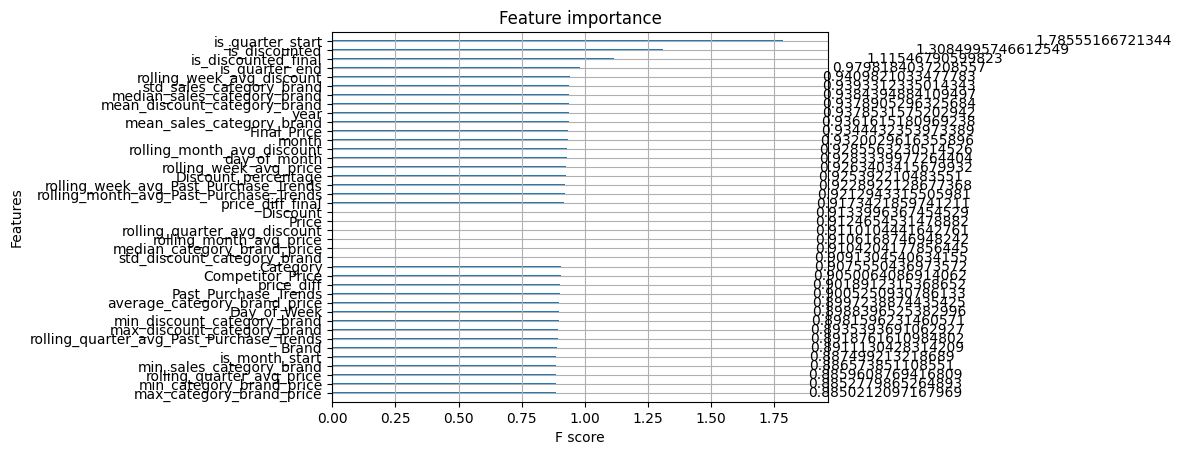

In [592]:
xgb.plot_importance(xgb_cluster_model, importance_type='gain', max_num_features=40)
plt.show()

In [593]:
feature_importance = xgb_cluster_model.get_score(importance_type='gain')

In [595]:
feature_importance_df = pd.DataFrame(feature_importance.items(), columns=['feature', 'importance']).sort_values(by='importance', ascending=False)

In [596]:
feature_importance_df['normalized_importance'] = feature_importance_df['importance'] / feature_importance_df['importance'].sum()

In [597]:
feature_importance_df['cumulative_importance'] = feature_importance_df['normalized_importance'].cumsum()

In [598]:
feature_importance_df.loc[feature_importance_df['cumulative_importance'] <= 0.95, 'feature']

16                            is_quarter_start
9                                is_discounted
22                         is_discounted_final
17                              is_quarter_end
34                   rolling_week_avg_discount
41                    std_sales_category_brand
40                 median_sales_category_brand
28                mean_discount_category_brand
10                                        year
39                   mean_sales_category_brand
20                                 Final_Price
11                                       month
36                  rolling_month_avg_discount
12                                day_of_month
33                      rolling_week_avg_price
18                         Discount_percentage
44       rolling_week_avg_Past_Purchase_Trends
45      rolling_month_avg_Past_Purchase_Trends
21                            price_diff_final
6                                     Discount
5                                        Price
38           

In [599]:
xgb_train_full = xgb.DMatrix(train_df.drop(columns=['Date', 'Sales_Quantity', 'cluster']), label=train_df['cluster'])

In [600]:
xgb_cluster_model_full = xgb.train(xgb_cluster_params, xgb_train_full, num_boost_round=700)

In [603]:
xgb_test = xgb.DMatrix(test_df.drop(columns=['Date', 'Sales_Quantity']))

In [604]:
test_df['cluster'] = xgb_cluster_model_full.predict(xgb_test)

In [605]:
test_df['pred_sales_quantity'] = kmean.cluster_centers_[test_df['cluster'].astype(int)]

In [606]:
test_df['pred_sales_quantity'] = test_df['pred_sales_quantity'].round()

In [607]:
test_df['pred_sales_quantity']

0       316.0
1       188.0
2       245.0
3        52.0
4       338.0
5       372.0
6       496.0
7       481.0
8       324.0
9       218.0
10       65.0
11       52.0
12      207.0
13      188.0
14      218.0
15       96.0
16       65.0
17      307.0
18      320.0
19      223.0
20      451.0
21      481.0
22      383.0
23      320.0
24      329.0
25      343.0
26      343.0
27      223.0
28      464.0
29      329.0
30      451.0
31       84.0
32      372.0
33      278.0
34      320.0
35      320.0
36      218.0
37      320.0
38       84.0
39      433.0
40      188.0
41      356.0
42      307.0
43      356.0
44       52.0
45      302.0
46       65.0
47      195.0
48      218.0
49      284.0
50       12.0
51       84.0
52      166.0
53      253.0
54      218.0
55      207.0
56      343.0
57      451.0
58      316.0
59      324.0
60      451.0
61      290.0
62       84.0
63      307.0
64      356.0
65       84.0
66      409.0
67      320.0
68      296.0
69      188.0
70      356.0
71    

In [608]:
min(test_df['pred_sales_quantity']), max(test_df['pred_sales_quantity'])

(12.0, 496.0)

In [609]:
submission_cluster = test_df['pred_sales_quantity']

In [613]:
submission_cluster.head()

0    316.0
1    188.0
2    245.0
3     52.0
4    338.0
Name: Sales_Quantity, dtype: float64

In [614]:
submission_cluster.to_csv("/Users/priyanshu.tuli/Desktop/machinehack/e-commerce_sales_dataset/submission_cluster.csv", index=False)